<a href="https://colab.research.google.com/github/panindarkwah/Neural_NetworkLab---3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


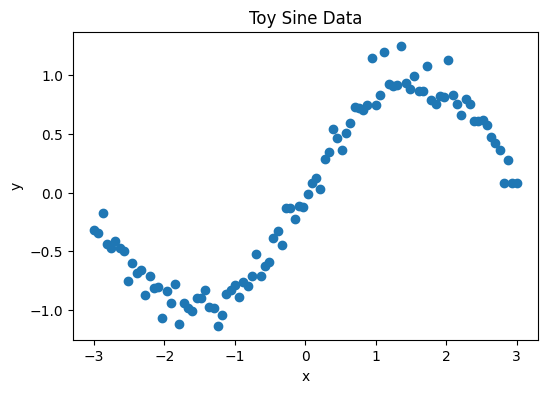

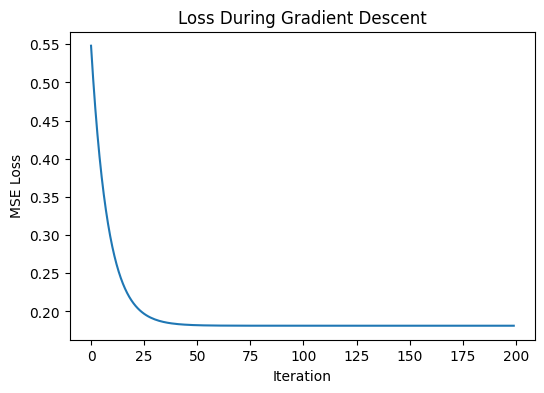

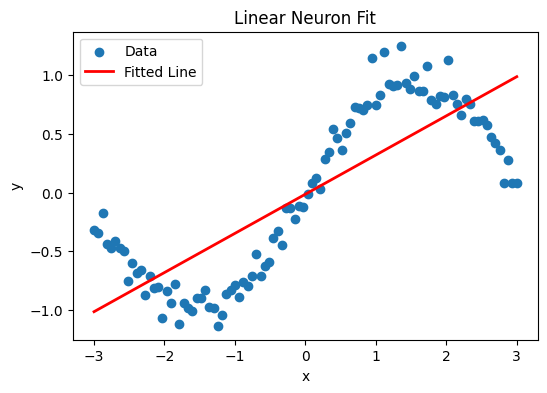

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
#   Plot it.
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Sine Data")
plt.show()


# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
# Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# Plot the fitted line
y_hat = w * x + b

#(b) the data with the fitted line on top.
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

1.
### Derivation of $\frac{\partial \text{Loss}}{\partial w}$

The prediction is:

$$
\hat{y} = wx + b
$$

The Mean Squared Error loss is:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Differentiate with respect to $w$:

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
2(\hat{y}_i-y_i)x_i
$$

Therefore,

$$
\frac{\partial L}{\partial w}
=
\text{mean}\left(2(\hat{y}-y)x\right)
$$

This matches the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

PART 1.1

2. The fit stops improving even though the fit is bad because, the single neuron only computes a linear function, hower the target data is generated from y = sin(x) + noise, which is a non-linear function. The gradient descent can only adjust the values of w and b; it cannot change the model from a straight line to a curve. After multiple iterations, it just finds the line that best fits, so the loss stops decreasing. To model the target, we need a model capable of representing nonlinear relationships, such as a neural network with one or more hidden layers and nonlinear activation functions
The poor fit is caused by underfitting because the model is too simple to represent the nonlinear pattern in the data.

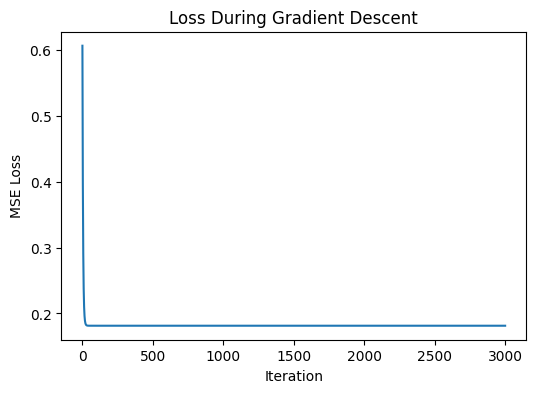

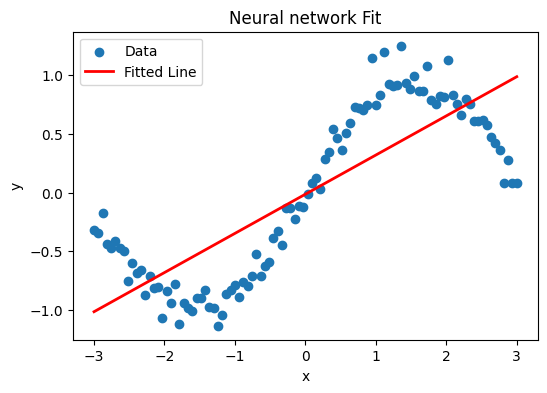

In [10]:
# TODO: Initialise parameters
w1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

w2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1,1)
y = y.reshape(-1,1)



# TODO: Implement ONE gradient-descent step by hand, then loop it for ~3000 steps:



# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ w1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ w2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ w2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
w1 -= lr * dW1
b1 -= lr * db1
w2 -= lr * dW2
b2 -= lr * db2
#   record the loss.
losses = []

for i in range(3000):

  z1 = x @ w1 + b1
  #h = np.tanh(z1)
  h = z1
  y_hat = h @ w2 + b2

  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh = d_yhat @ w2.T
  #dz1 = dh * (1 - np.tanh(z1) ** 2)
  dz1 = dh

  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  w1 -= lr * dW1
  b1 -= lr * db1
  w2 -= lr * dW2
  b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Neural network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


PART **1.2**
When the tanh is removed, the line fit becomes a strsight line.

1. With out the activation function, the networ =k becomes z1​=xW1​+b1​ and the output layer becomes y^​=z1​W2​+b2​. Substituting z1 into the second equation becomes
^​=(xW1​+b1​)W2​+b2​
^​=xW1​W2​+b1​W2​+b2​  this can be writeen a ^​=xW+b , they are jus new weights and biases. The equation is still a linear equation after stacking the multiple linear layers. The number of linear layers doesn't determine the model's ability to solve complex patterns, but the activation function is what introduces the non-linearity for the model to solve those complex patterns.

2. The hidden 8 neuron act as feature detectors, each neuron receives the input x, applies a different weight and bais , and produces a different nonlinear transformation. Becuase the activation funtion is non-linear aach neuron creates a different Curve feature of the input. The output feature then combines these 8 learned features to approximate the sine wave.

3. Backpropagation is an algorithm that examines when a neural network makes a prediction, checks how wrong it was, then sends the error backwards through the network to figure out which weights caused the mistake and how they could be adjusted.